В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [57]:
import pandas as pd
from google.colab import drive
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
import operator
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet

In [9]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


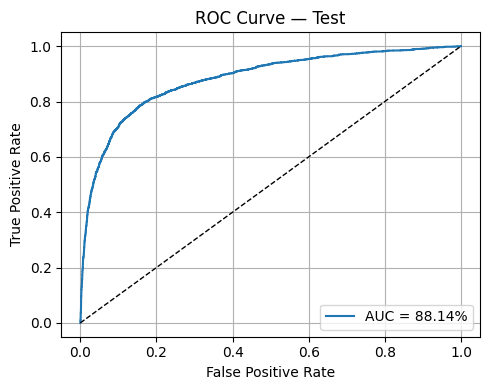

Area under ROC score on Test dataset: 0.88%


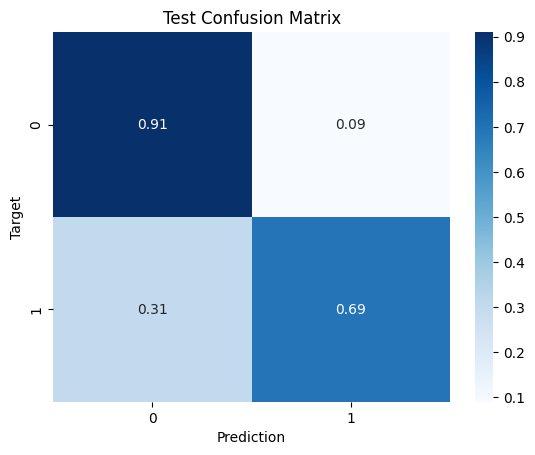

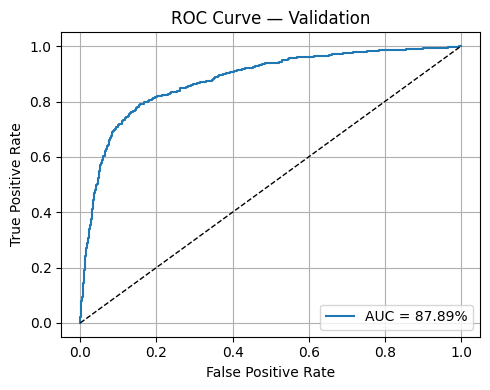

Area under ROC score on Validation dataset: 0.88%


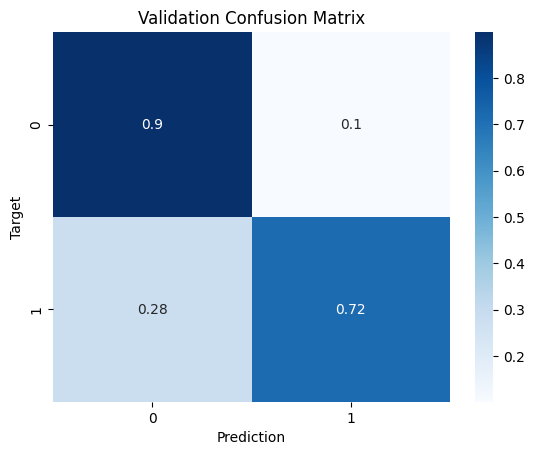

['clients_bank.joblib']

In [28]:
raw_df = pd.read_csv('drive/MyDrive/Colab Notebooks/train.csv', index_col=0)

train_df, val_df = train_test_split(raw_df, train_size= 0.8, random_state= 42, stratify= raw_df['Exited'])

# Створюємо трен. і вал. набори
input_cols = list(raw_df.columns)[3:-1]
target_col = 'Exited'
train_inputs, train_targets = train_df[input_cols], train_df[target_col]
val_inputs, val_targets = val_df[input_cols], val_df[target_col]

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include= np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include= 'object').columns.tolist()


# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    y_prob = model_pipeline.predict_proba(inputs)[:, 1]
    preds = (y_prob >= 0.34).astype(int)
    roc_auc = roc_auc_score(targets, y_prob)
    # Побудова ROC-кривої
    fpr, tpr, _ = roc_curve(targets, y_prob)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2%}')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {name}')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'Test')
val_preds = predict_and_plot(model_pipeline , val_inputs, val_targets, 'Validation')


# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'clients_bank.joblib')


**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

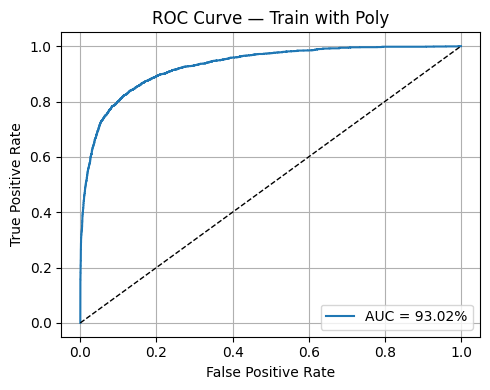

Area under ROC score on Train with Poly dataset: 0.93%


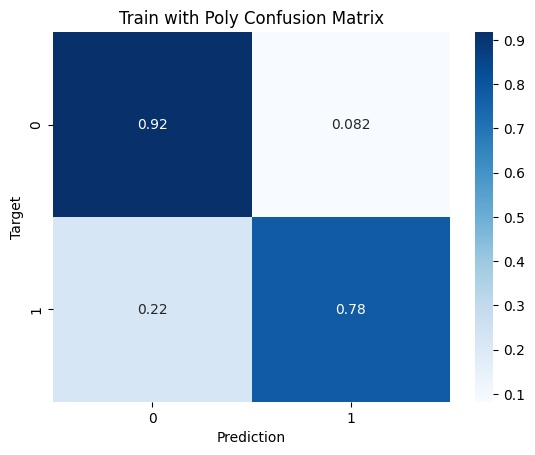

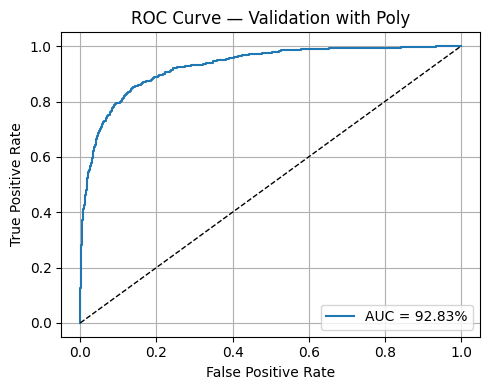

Area under ROC score on Validation with Poly dataset: 0.93%


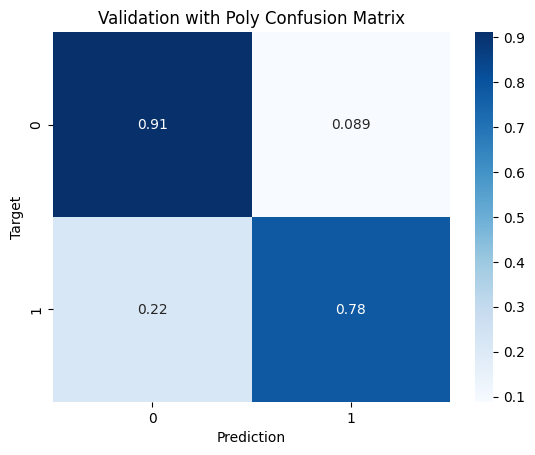

In [31]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])

preprocessor_poly = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

model_pipeline_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('classifier', LogisticRegression(max_iter=1000, solver='lbfgs'))
])

model_pipeline_poly.fit(train_inputs, train_targets)

train_preds = predict_and_plot(model_pipeline_poly, train_inputs, train_targets, 'Train with Poly')
val_preds = predict_and_plot(model_pipeline_poly, val_inputs, val_targets, 'Validation with Poly')



ROC - train 93.02 , validation 92.83, \
Різниця між тренувальним набором та валідаційним 0.0019, що менше 0.05, а отже модель добре генералізує та немає ознак overfitting чи underfitting

In [39]:
sample_submission = pd.read_csv('drive/MyDrive/Colab Notebooks/sample_submission.csv')
test_df = pd.read_csv('drive/MyDrive/Colab Notebooks/test.csv')

test_inputs = test_df[numeric_cols + categorical_cols]
test_preds = model_pipeline_poly.predict(test_inputs)

sample_submission['Exited'] = test_preds
sample_submission.to_csv('submission_log_reg.csv', index=False)

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

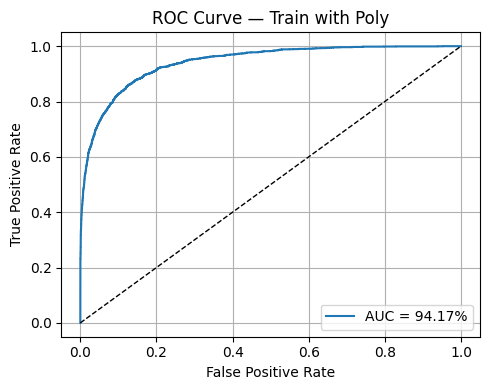

Area under ROC score on Train with Poly dataset: 0.94%


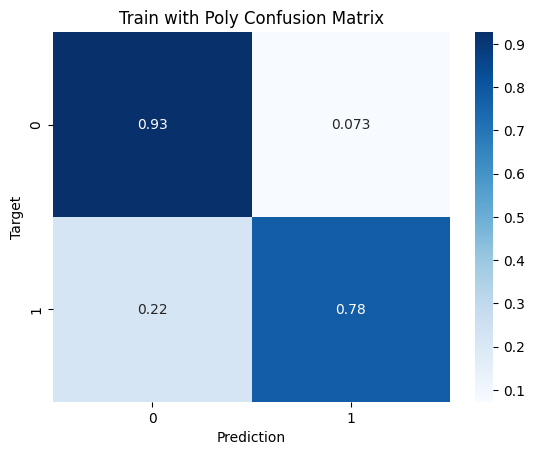

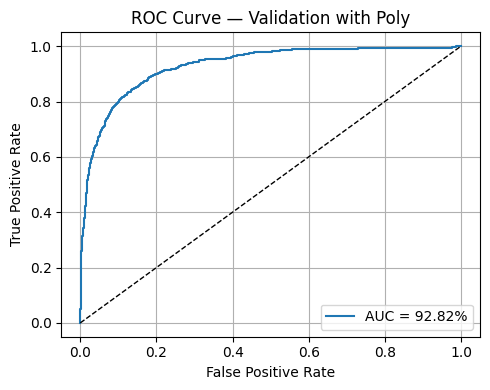

Area under ROC score on Validation with Poly dataset: 0.93%


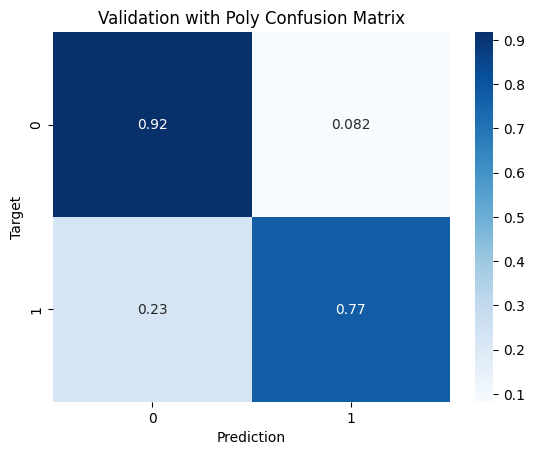

In [40]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=4, include_bias=False))
])

preprocessor_poly = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

model_pipeline_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('classifier', LogisticRegression(max_iter=1000, solver='lbfgs'))
])

model_pipeline_poly.fit(train_inputs, train_targets)

train_preds = predict_and_plot(model_pipeline_poly, train_inputs, train_targets, 'Train with Poly')
val_preds = predict_and_plot(model_pipeline_poly, val_inputs, val_targets, 'Validation with Poly')

ROC - train 94.17 , validation 92.83,
Різниця між тренувальним набором та валідаційним 0.0134, що менше 0.05, а отже модель добре генералізує та немає ознак overfitting чи underfitting

In [41]:
test_inputs = test_df[numeric_cols + categorical_cols]
test_preds = model_pipeline_poly.predict(test_inputs)

sample_submission['Exited'] = test_preds
sample_submission.to_csv('submission_log_reg.csv', index=False)

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


Train with Poly — RMSE: 0.000, R²: 1.000


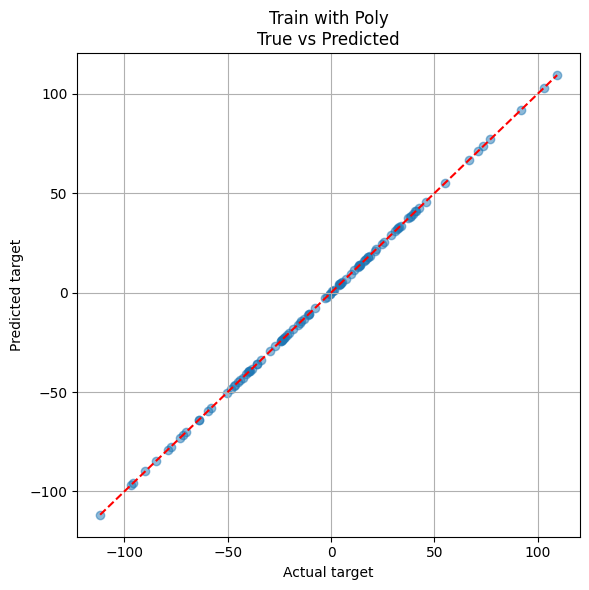

Test with Poly — RMSE: 35.628, R²: 0.456


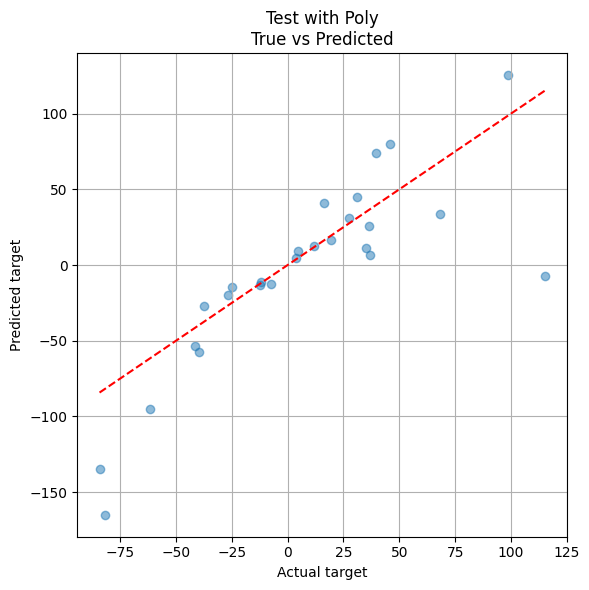

In [55]:
reg_data = pd.read_csv('drive/MyDrive/Colab Notebooks/regression_data.csv')
train_df, test_df = train_test_split(reg_data, train_size= 0.8, random_state= 42)

# Створюємо трен. і тест. набори
input_cols = list(reg_data.columns)[:-1]
target_col = 'target'
train_inputs, train_targets = train_df[input_cols], train_df[target_col]
test_inputs, test_targets = test_df[input_cols], test_df[target_col]

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=5, include_bias=False))
])

model_pipeline_poly = Pipeline(steps=[
    ('transformer', numeric_transformer),
    ('classifier', LinearRegression())
])

model_pipeline_poly.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot_regression(model, X, y_true, title=''):
    # Отримуємо передбачення
    y_pred = model.predict(X)

    # RMSE і R²
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"{title} — RMSE: {rmse:.3f}, R²: {r2:.3f}")

    # Побудова графіка: реальні vs передбачені
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')  # ідеальна лінія
    plt.xlabel('Actual target')
    plt.ylabel('Predicted target')
    plt.title(f'{title}\nTrue vs Predicted')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return y_pred


train_preds = predict_and_plot_regression(model_pipeline_poly, train_inputs, train_targets, 'Train with Poly')
test_preds = predict_and_plot_regression(model_pipeline_poly, test_inputs, test_targets, 'Test with Poly')

In [52]:
std_target = reg_data['target'].std()
print(f"Std of target: {std_target:.2f}")
mean = np.mean(train_targets)
print(mean)


Std of target: 45.47
-6.450753928428644


train RMSE:  0.000, R²: 0.999\
test RMSE: 35.628,, R²: 0.456\
RMSE на train ≈ 0 модель майже ідеально запам’ятала тренувальні дані.\
Але test RMSE = 35.6, і R² = 0.456 — це означає:\
модель не відтворює закономірностей на нових прикладах
вона просто “вивчила” тренувальні точки, а не зрозуміла залежність\
Це overfitting — модель надто складна для структури даних

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.331e+03, tolerance: 2.006e+01
  model = cd_fast.enet_coordinate_descent(


Train with Poly — RMSE: 2.263, R²: 0.997


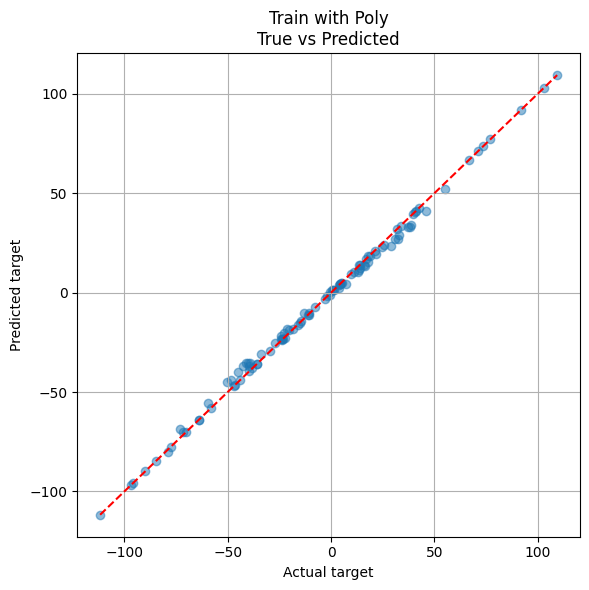

Test with Poly — RMSE: 104.423, R²: -3.674


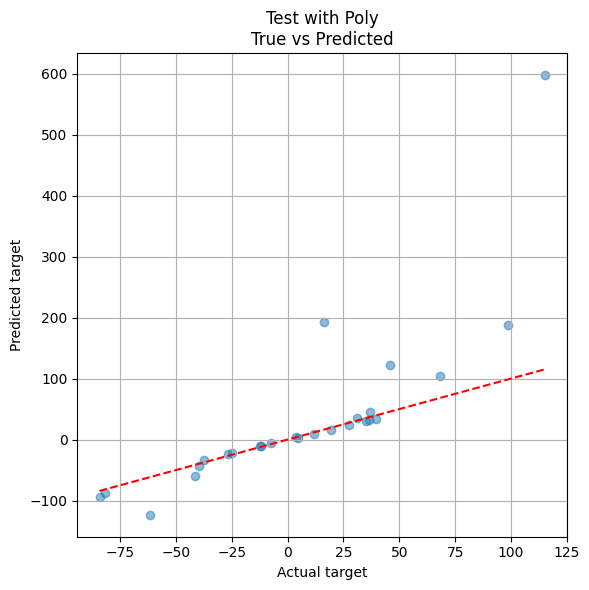

In [56]:
#Lasso
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=20, include_bias=False))
])

model_pipeline_poly = Pipeline(steps=[
    ('transformer', numeric_transformer),
    ('regressor', Lasso(alpha=1.0, max_iter=10000))
])

model_pipeline_poly.fit(train_inputs, train_targets)


train_preds = predict_and_plot_regression(model_pipeline_poly, train_inputs, train_targets, 'Train with Poly')
test_preds = predict_and_plot_regression(model_pipeline_poly, test_inputs, test_targets, 'Test with Poly')

train RMSE: 2.263, R²: 0.997\
test RMSE: 104.423, R²: -3.674\
модель практично "вивчила напам’ять" тренувальні дані.
Test R² = –3.674 означає, що модель гірша, ніж просто середнє по target.
Test RMSE = 104.4 при std ≈ 45.5 → похибка більша за подвійне стандартне відхилення. \
Це явно Overfitting


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


Train with Poly — RMSE: 31.617, R²: 0.487


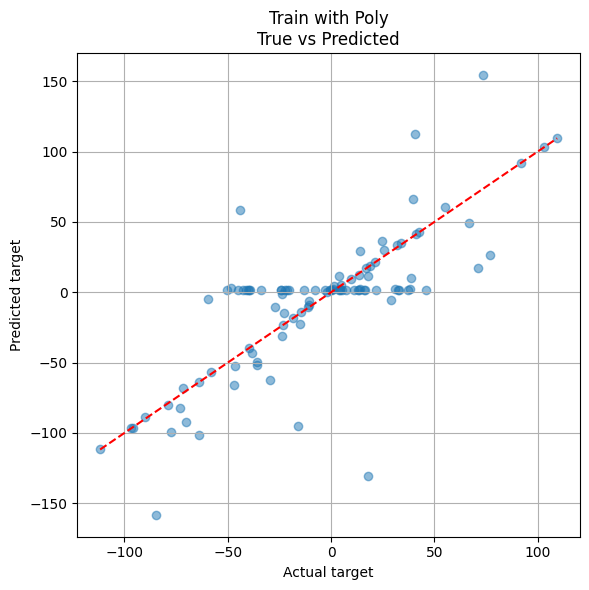

Test with Poly — RMSE: 191972.905, R²: -15796210.574


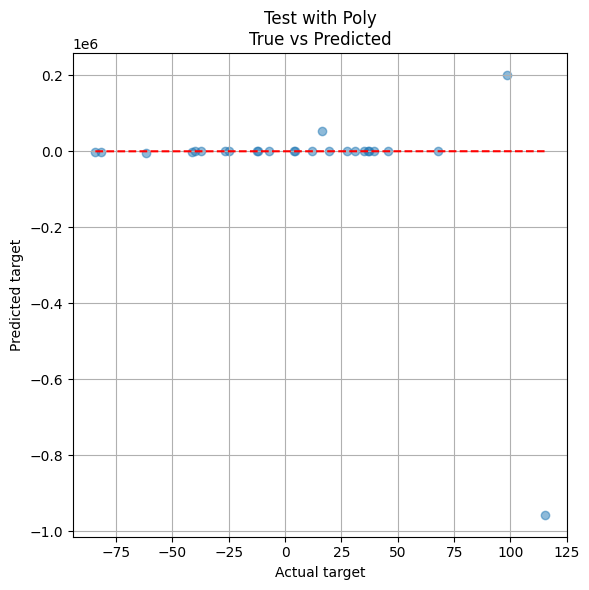

In [58]:
#Ridge()
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=20, include_bias=False))
])

model_pipeline_poly = Pipeline(steps=[
    ('transformer', numeric_transformer),
    ('regressor', Ridge(alpha=1.0, max_iter=10000))
])

model_pipeline_poly.fit(train_inputs, train_targets)


train_preds = predict_and_plot_regression(model_pipeline_poly, train_inputs, train_targets, 'Train with Poly')
test_preds = predict_and_plot_regression(model_pipeline_poly, test_inputs, test_targets, 'Test with Poly')

train RMSE: 31.617, R²: 0.487\
test RMSE: 191972.905, R²: -15796210.574\
модель навіть на тренуванні слабко пояснює залежність.\
Тут глибокий underfitting, схоже що модель взагалі не розуміє, що їй потрібно робити




/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.488e+03, tolerance: 2.006e+01
  model = cd_fast.enet_coordinate_descent(


Train with Poly — RMSE: 9.148, R²: 0.957


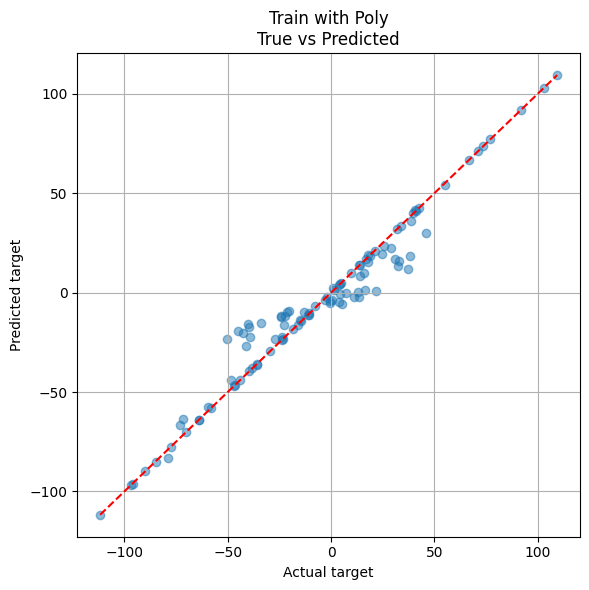

Test with Poly — RMSE: 241.664, R²: -24.032


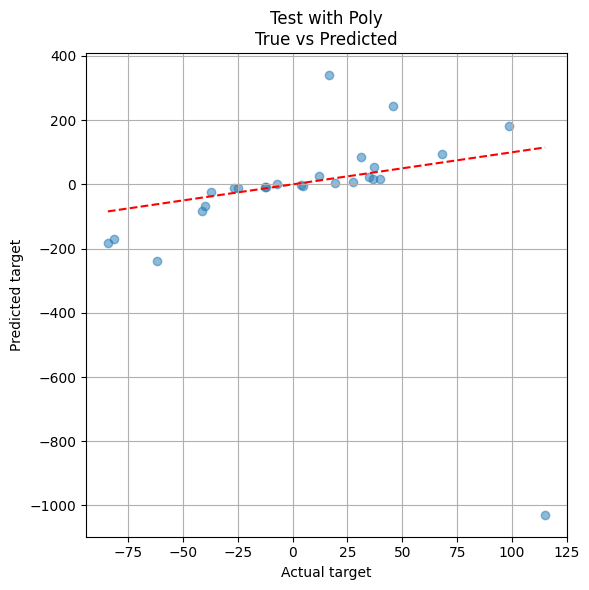

In [60]:
#ElastycNet ()
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=20, include_bias=False))
])

model_pipeline_poly = Pipeline(steps=[
    ('transformer', numeric_transformer),
    ('regressor', ElasticNet(alpha=1.0, l1_ratio=0.5))
])

model_pipeline_poly.fit(train_inputs, train_targets)


train_preds = predict_and_plot_regression(model_pipeline_poly, train_inputs, train_targets, 'Train with Poly')
test_preds = predict_and_plot_regression(model_pipeline_poly, test_inputs, test_targets, 'Test with Poly')

train RMSE: 9.148, R²: 0.957\
test RMSE: 241.664, R²: -24.032\
Модель досить добре вивчила train, але повністю зламалась на нових даних.
Це overfitting

На мій погляд, поліном у 20-му степені це занадто багато ознак, але я б взяла еластікнет, та поекспериментувала з нею, від зменшення поліному до визначення штрафів, оскільки вона поєднує в собі і лассо і рідж.